Day 1

1 & 2) Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('downloads/traffic_weather_data.csv', parse_dates=['date'])

print("Dataset Head:")
print(df.head())

print(f"\nDataset Shape: {df.shape}")

Dataset Head:
   driver_id       date  temperature_c  rainfall_mm  humidity  delays_minutes  \
0        101 2026-03-01           33.4          0.0      62.0            17.0   
1        101 2026-03-02           23.9          0.0      44.7             8.0   
2        101 2026-03-03           32.4          0.0      58.0             8.0   
3        101 2026-03-04           33.6          5.9      89.1            30.0   
4        101 2026-03-05           24.2          0.0      45.5            16.0   

   behavioral_problems  violations_count  accidents_count  rating  
0                  0.0               0.0              0.0     4.9  
1                  0.0               0.0              0.0     4.9  
2                  0.0               0.0              0.0     4.9  
3                  0.0               1.0              0.0     4.3  
4                  0.0               0.0              0.0     4.9  

Dataset Shape: (300, 10)


3) Data Inspection (Exploration)

In [2]:
print("Data Information:")
print(df.info())

print("\nSummary Statistics:")
print(df[['temperature_c', 'rainfall_mm', 'delays_minutes']].describe())

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   driver_id            300 non-null    int64         
 1   date                 300 non-null    datetime64[ns]
 2   temperature_c        300 non-null    float64       
 3   rainfall_mm          300 non-null    float64       
 4   humidity             300 non-null    float64       
 5   delays_minutes       300 non-null    float64       
 6   behavioral_problems  300 non-null    float64       
 7   violations_count     300 non-null    float64       
 8   accidents_count      300 non-null    float64       
 9   rating               300 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 23.6 KB
None

Summary Statistics:
       temperature_c  rainfall_mm  delays_minutes
count     300.000000   300.000000      300.0000

4) Visualize Correlations (Data Exploration)

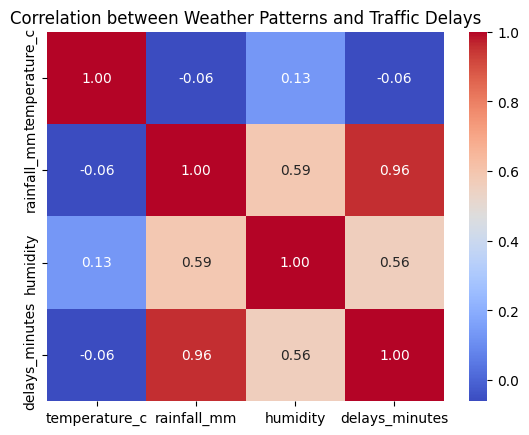

In [3]:
corr = df[['temperature_c', 'rainfall_mm', 'humidity', 'delays_minutes']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Weather Patterns and Traffic Delays")
plt.show()

5) Specific Relationship Plots

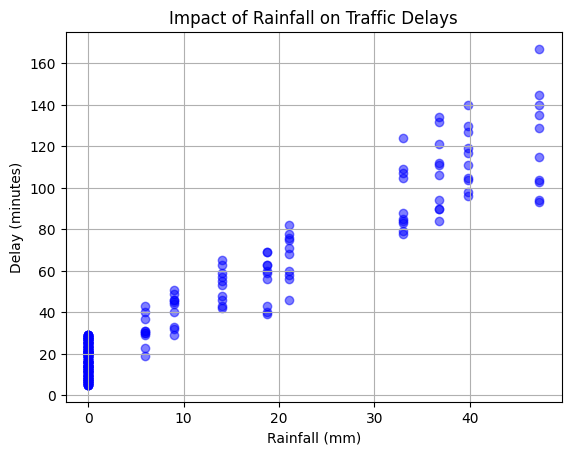

In [4]:
plt.scatter(df['rainfall_mm'], df['delays_minutes'], alpha=0.5, color='blue')
plt.title("Impact of Rainfall on Traffic Delays")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Delay (minutes)")
plt.grid(True)
plt.show()

Day 2

1) Basic Helpers & Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(filepath, date_col=None, parse_dates=True):
    if filepath.lower().endswith(('.csv', '.txt')):
        df = pd.read_csv(filepath, parse_dates=[date_col] if (parse_dates and date_col) else None)
    return df

def normalize_column_names(df):
    df = df.copy()
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    return df

df = load_data("downloads/traffic_weather_data.csv", date_col='date')
df = normalize_column_names(df)
print("Step 1: Data Loaded and Columns Normalized.")

Step 1: Data Loaded and Columns Normalized.


2) Cleaning & Imputation

In [6]:
def basic_clean(df):
    obj_cols = df.select_dtypes(include='object').columns
    for c in obj_cols:
        df[c] = df[c].astype(str).str.strip()
    return df

def fill_missing(df, strategy_map=None, global_strategy='median'):
    df = df.copy()
    for col in df.columns:
        if df[col].isnull().sum() == 0: continue
        if global_strategy == 'median' and pd.api.types.is_numeric_dtype(df[col]):
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(0, inplace=True)
    return df

df = basic_clean(df)
df = fill_missing(df)
print("Step 2: Cleaning and Imputation Complete.")

Step 2: Cleaning and Imputation Complete.


3) Datetime Features

In [7]:
def extract_datetime_features(df, date_col):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['weekday'] = df[date_col].dt.weekday
    df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
    return df

df = extract_datetime_features(df, 'date')
print("Step 3: Datetime Features Extracted.")

Step 3: Datetime Features Extracted.


4) Outlier Handling

In [8]:
def remove_outliers_iqr(df, cols, factor=1.5):
    """Remove rows where any column in cols is outside the IQR fence."""
    df = df.copy()
    mask = pd.Series(True, index=df.index)
    for c in cols:
        if not pd.api.types.is_numeric_dtype(df[c]):
            continue
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        mask &= df[c].between(lower, upper)
    return df[mask]

df = remove_outliers_iqr(df, cols=['delays_minutes', 'rating'])
print("Step 4: Outliers removed based on IQR.")

Step 4: Outliers removed based on IQR.


5) Lag/Rolling Features (for time series)

In [9]:
def create_lag_features(df, group_col, target_col, lags=[1,7,14], roll_windows=[7]):
    df = df.copy()
    if group_col:
        grp = df.groupby(group_col)
        for lag in lags:
            df[f'{target_col}_lag_{lag}'] = grp[target_col].shift(lag)
        for w in roll_windows:
            df[f'{target_col}_roll_mean_{w}'] = grp[target_col].shift(1).rolling(window=w).mean().reset_index(level=0, drop=True)
    return df

df = create_lag_features(df, group_col='driver_id', target_col='delays_minutes')

df = df.dropna().reset_index(drop=True)
print("Step 5: Lag and Rolling features created.")

Step 5: Lag and Rolling features created.


6) Encoding and Scaling Pipeline

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def build_preprocessing_pipeline(df, numeric_cols=None, categorical_cols=None, scaler=StandardScaler, encoder=OneHotEncoder):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    numeric_transformer = Pipeline(steps=[('scaler', scaler())])
    categorical_transformer = Pipeline(steps=[('onehot', encoder(handle_unknown='ignore', sparse=False))])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='drop'
    )
    return preprocessor, numeric_cols, categorical_cols

print("Step 6: Preprocessing Pipeline function defined.")

Step 6: Preprocessing Pipeline function defined.


7) Correlation Heatmaps

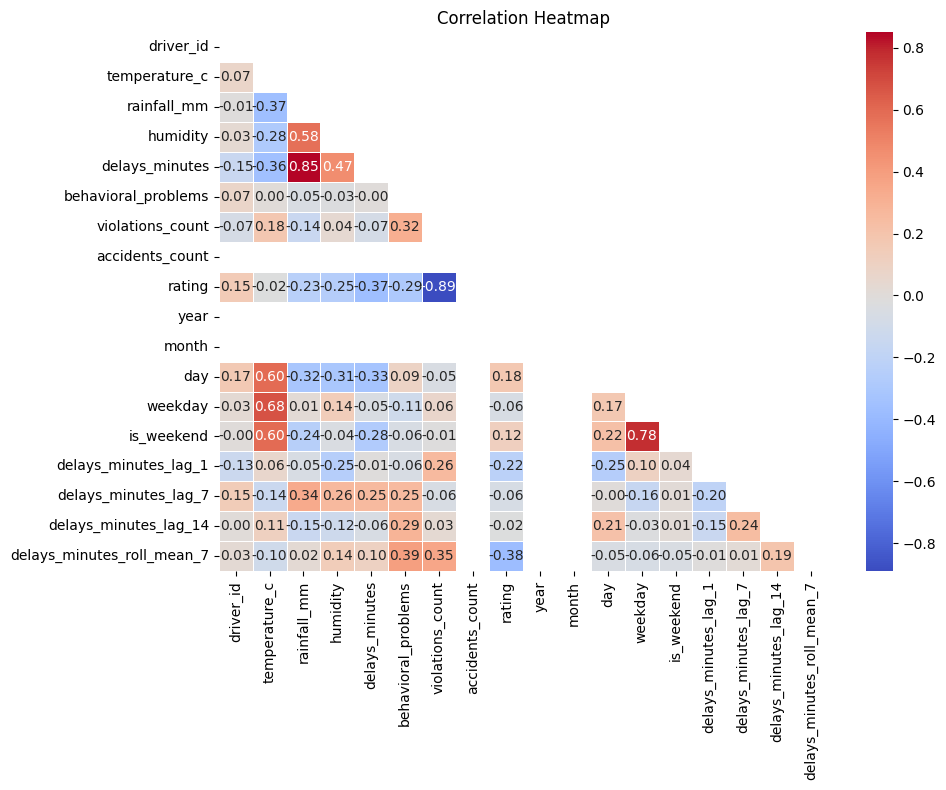

In [11]:
def correlation_matrix(df, method='pearson'):
    num_df = df.select_dtypes(include=[np.number]).copy()
    return num_df.corr(method=method)

def plot_corr_heatmap(corr, figsize=(10,8), annot=True, cmap='coolwarm', mask_upper=True):
    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr, dtype=bool)) if mask_upper else None
    sns.heatmap(corr, annot=annot, fmt=".2f", cmap=cmap, mask=mask, linewidths=.5)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

corr = correlation_matrix(df)
plot_corr_heatmap(corr)

8) Prepare Final Dataset for Training

In [12]:
from sklearn.model_selection import train_test_split

def prepare_final_dataset(df, target_col, date_col=None, test_size=0.2, time_series=True):
    df = df.copy()
    df = df[~df[target_col].isnull()]
    
    if time_series and date_col:
        df_sorted = df.sort_values(by=date_col)
        n = len(df_sorted)
        split_idx = int(np.floor((1 - test_size) * n))
        train_df = df_sorted.iloc[:split_idx]
        test_df = df_sorted.iloc[split_idx:]
        
        X_train = train_df.drop(columns=[target_col, date_col])
        y_train = train_df[target_col]
        X_test = test_df.drop(columns=[target_col, date_col])
        y_test = test_df[target_col]
        
        return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_final_dataset(df, target_col='delays_minutes', date_col='date')

print(f"Step 8: Final datasets prepared!")
print(f"Training features shape: {X_train.shape}")
print("X_test shape:", X_test.shape)

Step 8: Final datasets prepared!
Training features shape: (48, 17)
X_test shape: (12, 17)


Day 3

1) Get Weather Data (Open-Meteo)

In [13]:
import requests
import pandas as pd

params = {
    "latitude": 14.5995, "longitude": 120.9842,
    "hourly": "temperature_2m,precipitation",
    "start_date": "2026-03-01", 
    "end_date": "2026-03-08",
    "timezone": "Asia/Manila"
}

r = requests.get("https://api.open-meteo.com/v1/forecast", params=params)
weather_data = r.json()["hourly"]

df_weather = pd.DataFrame(weather_data)
df_weather['time'] = pd.to_datetime(df_weather['time'])
df_weather.to_csv("data/weather_raw.csv", index=False)

print("Step 1 Complete: Weather data saved.")

Step 1 Complete: Weather data saved.


2) Preprocess & Merge (EDA)

In [24]:
df_delays = pd.read_csv("downloads/traffic_weather_data.csv", parse_dates=["date"])

df_delays = df_delays.rename(columns={"date": "timestamp", "delays_minutes": "delay_minutes"})

df = df_delays.fillna(0)
df.to_csv("delay-weather-dashboard/data/merged_hourly.csv", index=False)

print("Step 2 Complete: merged_hourly.csv created.")

Step 2 Complete: merged_hourly.csv created.


3) Build Forecast Models (Prophet & ML)

3-A&B

In [25]:
from prophet import Prophet
import pandas as pd

df['moving_avg_7d'] = df['delay_minutes'].rolling(window=7).mean()

df_prophet = df[['timestamp', 'delay_minutes']].reset_index().rename(columns={'timestamp':'ds', 'delay_minutes':'y'})

m = Prophet(weekly_seasonality=True, daily_seasonality=False)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=7, freq='D')
forecast = m.predict(future)

forecast[['ds', 'yhat']].to_csv('delay-weather-dashboard/data/forecast.csv', index=False)

print("Steps 3-A & B Complete: Baseline calculated and Prophet forecast saved.")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

15:54:56 - cmdstanpy - INFO - Chain [1] start processing
15:54:56 - cmdstanpy - INFO - Chain [1] done processing


Steps 3-A & B Complete: Baseline calculated and Prophet forecast saved.
           ds       yhat  yhat_lower  yhat_upper
32 2026-04-02  11.576614  -26.209850   47.595334
33 2026-04-03  10.652224  -21.698037   46.539055
34 2026-04-04  -5.775768  -40.788420   28.294744
35 2026-04-05  15.606230  -20.685618   49.921251
36 2026-04-06  18.012583  -20.178514   54.683889


4) Visualization: Delay Forecasts vs Weather Trends

In [16]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

forecast = pd.read_csv('data/forecast.csv', parse_dates=['ds'])
df_hourly = pd.read_csv('data/merged_hourly.csv', parse_dates=['timestamp'])

vis = df_hourly.merge(forecast.rename(columns={'ds':'timestamp'}), on='timestamp', how='left')

fig = go.Figure()

fig.add_trace(go.Scatter(x=vis.timestamp, y=vis.delay_minutes, name='Actual Delays', line=dict(color='blue')))

fig.add_trace(go.Scatter(x=vis.timestamp, y=vis.yhat, name='Forecast Delays', line=dict(dash='dash', color='red')))

fig.add_trace(go.Bar(x=vis.timestamp, y=vis.rainfall_mm, name='Precipitation', yaxis='y2', opacity=0.4, marker_color='lightblue'))

fig.update_layout(
    title="Interactive Forecast: Traffic Delays vs. Rainfall Trends",
    yaxis=dict(title="Delay (Minutes)"),
    yaxis2=dict(title="Precipitation (mm)", overlaying='y', side='right'),
    legend=dict(x=0, y=1.1, orientation='h'),
    hovermode="x unified"
)

fig.show()

Day 4

C:\Users\JERMAGNE\AppData\Local\Temp\ipykernel_5136\4042780576.py:49: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(df.mean())


Linear Regression — MAE: 3.795, RMSE: 4.514, R2: 0.978
Random Forest — MAE: 5.888, RMSE: 9.889, R2: 0.894


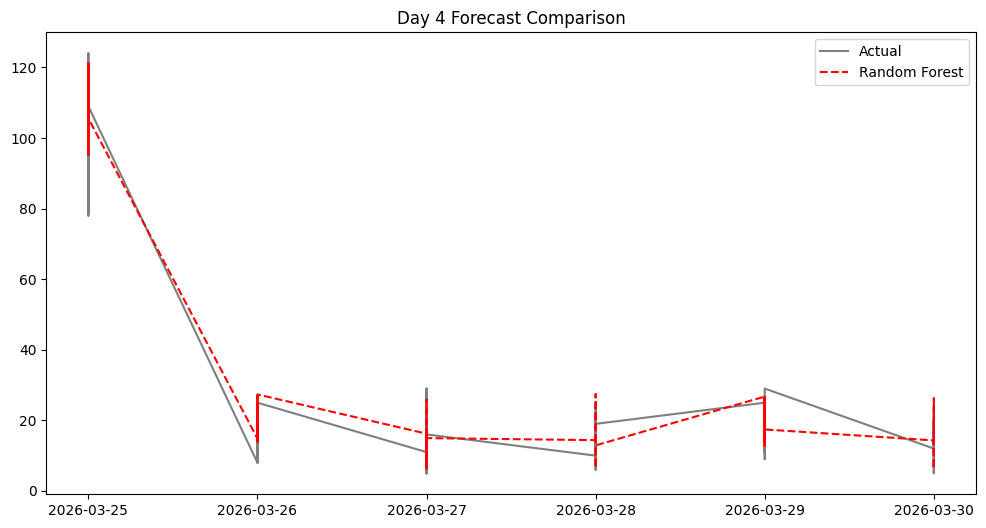

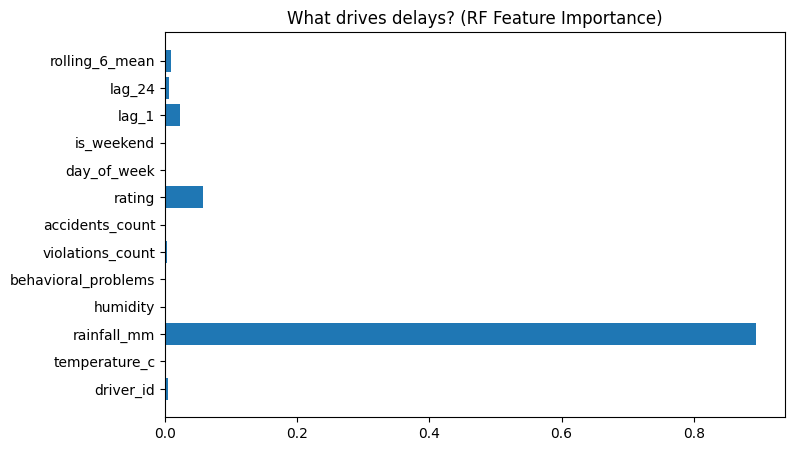

Models saved successfully in 'models/' folder.


In [31]:
"""
forecast_compare.py
Train baseline Linear Regression vs RandomForestRegressor
on delivery delay data and visualize prediction vs actual.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import dump
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def load_data(path=r"data/merged_hourly.csv"):
    """Load your real dataset."""
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=['timestamp'])
        df = df.rename(columns={'timestamp': 'date', 'delay_minutes': 'delays_minutes'})
        df = df.sort_values('date').reset_index(drop=True)
        return df
    else:
        print(f"Error: {path} not found. Ensure Step 2 was completed.")
        return None

def create_features(df):
    """Create time-based, lag, and weather features."""
    df = df.copy()
    df.set_index('date', inplace=True)

    df['day_of_week'] = df.index.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    df['lag_1'] = df['delays_minutes'].shift(1)
    df['lag_24'] = df['delays_minutes'].shift(24)

    df['rolling_6_mean'] = df['delays_minutes'].rolling(window=6).mean().shift(1)

    df = df.fillna(method='bfill').fillna(df.mean())
    return df

def train_test_split_time_series(df, test_size=0.2):
    n = len(df)
    split_at = int(n * (1 - test_size))
    train = df.iloc[:split_at]
    test = df.iloc[split_at:]
    return train, test

def evaluate_model(y_true, y_pred, prefix="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse) 
    
    r2 = r2_score(y_true, y_pred)
    print(f"{prefix} — MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

def main():
    df_raw = load_data()
    if df_raw is None: return

    df = create_features(df_raw)
    target_col = 'delays_minutes'
    feature_cols = [c for c in df.columns if c != target_col]

    train_df, test_df = train_test_split_time_series(df, test_size=0.2)
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_test, y_test = test_df[feature_cols], test_df[target_col]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    evaluate_model(y_test, lr_pred, prefix="Linear Regression")

    rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    evaluate_model(y_test, rf_pred, prefix="Random Forest")

    plt.figure(figsize=(12, 6))
    plt.plot(test_df.index, y_test, label='Actual', color='black', alpha=0.5)
    plt.plot(test_df.index, rf_pred, label='Random Forest', color='red', linestyle='--')
    plt.title("Day 4 Forecast Comparison")
    plt.legend()
    plt.show()

    importances = rf.feature_importances_
    plt.figure(figsize=(8,5))
    plt.barh(feature_cols, importances)
    plt.title("What drives delays? (RF Feature Importance)")
    plt.show()

    if not os.path.exists('models'): os.makedirs('models')
    dump(lr, 'delay-weather-dashboard/models/linear_regression.joblib')
    dump(rf, 'delay-weather-dashboard/models/rf_delay.pkl')
    print("Models saved successfully in 'models/' folder.")

if __name__ == "__main__":
    main()